In [ ]:
import os
import random
import shutil


if os.path.exists("cats_dogs_split"):
    shutil.rmtree("cats_dogs_split")

def safe_split_dataset(source_dir, output_dir, train_percentage=80):
    classes = ["Cat", "Dog"] 
    
    if not os.path.exists(source_dir):
        print(f"CRITICAL ERROR: Cannot find the folder -> {source_dir}")
        return

    for class_name in classes:
        source_class = os.path.join(source_dir, class_name)
        images = [f for f in os.listdir(source_class) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
                
        random.shuffle(images) 
        split_index = int(len(images) * train_percentage / 100) 
        
        train_images = images[:split_index]
        test_images = images[split_index:]
        
        train_folder = os.path.join(output_dir, "train", class_name)
        test_folder = os.path.join(output_dir, "test", class_name)
        
        os.makedirs(train_folder, exist_ok=True) 
        os.makedirs(test_folder, exist_ok=True)-
        
        for image in train_images:
            shutil.copy2(os.path.join(source_class, image), os.path.join(train_folder, image))
        for image in test_images:
            shutil.copy2(os.path.join(source_class, image), os.path.join(test_folder, image))
            
        print(f" Setup {class_name}: {len(train_images)} Training images, {len(test_images)} Testing images.")

print("Building Data Pipeline...")

safe_split_dataset(source_dir=r".\archive (2)\kagglecatsanddogs_3367a\dataset", output_dir="cats_dogs_split", train_percentage=80)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

print(" Loading datasets from the newly created folders...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "cats_dogs_split/train",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "cats_dogs_split/test",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

print("\n Building your Upgraded Augmented Neural Network...")
model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') 
])

model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy'] 
)

print("\n Starting Training... (With 15 epochs, grab a snack!)")
history = model.fit(
    train_dataset,
    validation_data=test_dataset, 
    epochs=15
)

print(" Training Complete! Your AI is now highly trained.")

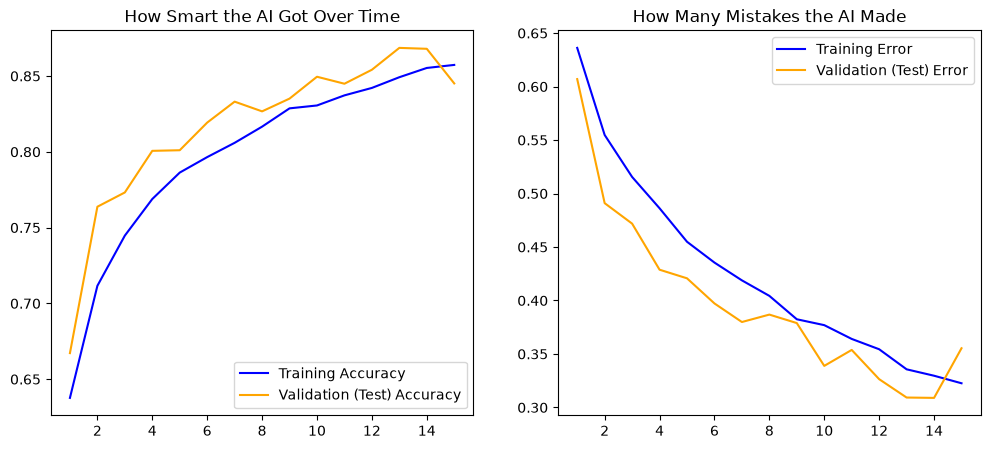

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


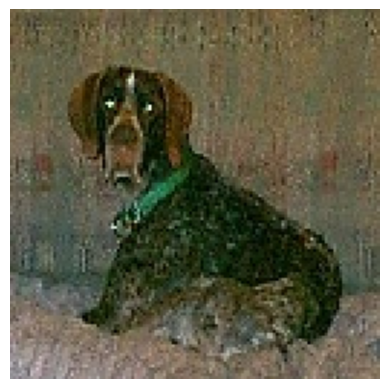


 Prediction: IT'S A DOG! (Confidence: 87.99%)


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import random
import os


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation (Test) Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('How Smart the AI Got Over Time')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Error', color='blue')
plt.plot(epochs_range, val_loss, label='Validation (Test) Error', color='orange')
plt.legend(loc='upper right')
plt.title('How Many Mistakes the AI Made')
plt.show()


test_dir = "cats_dogs_split/test/Dog"


available_images = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random_image_name = random.choice(available_images)
test_image_path = os.path.join(test_dir, random_image_name)


img = tf.keras.utils.load_img(test_image_path, target_size=(128, 128))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) 


prediction = model.predict(img_array)


plt.imshow(img)
plt.axis('off')
plt.show()

if prediction[0][0] < 0.5:
    print(f"\n Prediction: IT'S A CAT! (Confidence: {((1 - prediction[0][0]) * 100):.2f}%)")
else:
    print(f"\n Prediction: IT'S A DOG! (Confidence: {(prediction[0][0] * 100):.2f}%)")